# NomadOptima — Notebook 03: LightGBM Ranker

**Objetivo:** Entrenar un modelo de Learning to Rank con LightGBM (algoritmo LambdaRank)  
para ordenar ciudades por relevancia dado un perfil de usuario.

**Input:** `data/processed/training_dataset.csv` (60.000 filas — generado en notebook 02)  
**Output:**
- Modelo entrenado guardado en MLflow
- `data/processed/lgbm_feature_importance.png`
- `data/processed/shap_summary.png`
- `data/processed/shap_waterfall_arquetipos.png`

**Métricas objetivo:** NDCG@1, NDCG@2, Precision@1  
**MLflow experiment:** `NomadOptima_LightGBM_Ranker`

---

## Paso 0: Imports y carga del dataset

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import shap
import mlflow
import mlflow.lightgbm
from sklearn.metrics import ndcg_score as sklearn_ndcg

np.random.seed(42)

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
COLORS = {'Malaga': '#2E86AB', 'Paris': '#E67E22', 'Valencia': '#27AE60', 'Porto': '#8E44AD', 'Bordeaux': '#C0392B'}
COLORS_ARQ = ['#2E86AB','#E67E22','#27AE60','#8E44AD',
               '#E74C3C','#F39C12','#1ABC9C','#2C3E50']

# Cargar dataset generado en notebook 02
df = pd.read_csv('../data/processed/training_dataset.csv')
print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'\nPrimeras columnas: {list(df.columns[:6])} ...')
print(f'\nDistribucion de relevancia:')
nombres_rel = {0: 'Irrelevante', 1: 'Bajo', 2: 'Relevante', 3: 'Muy relevante'}
for label, cnt in df['relevance'].value_counts().sort_index().items():
    print(f'  {label} — {nombres_rel[label]:<15}: {cnt:>7,} ({cnt/len(df)*100:.1f}%)')

Dataset cargado: 150,000 filas x 88 columnas

Primeras columnas: ['query_id', 'city', 'arquetipo', 'relevance', 'user_presupuesto_max', 'user_temp_min_c'] ...

Distribucion de relevancia:
  0 — Irrelevante    :  57,739 (38.5%)
  1 — Bajo           :  43,820 (29.2%)
  2 — Relevante      :  48,039 (32.0%)
  3 — Muy relevante  :     402 (0.3%)


OBSERVACIONES:
- El dataset tiene 60.000 filas: 30.000 perfiles × 2 ciudades (Málaga y París)
- Cada fila = una combinación (perfil, ciudad) con su etiqueta de relevancia 0-3
- La distribución de relevancia debe ser desbalanceada — la mayoría serán 1 o 2

ANOTACIONES:
- **Learning to Rank (LTR):** un tipo de problema de ML donde el objetivo no es
  clasificar ni regresionar un valor, sino **ordenar** un conjunto de documentos
  (ciudades) dados una consulta (perfil de usuario).
- **¿Por qué no usar clasificación o regresión?** Porque lo que importa no es
  predecir el valor exacto de relevancia, sino que la ciudad más relevante aparezca
  PRIMERA en la lista. El orden relativo importa más que el valor absoluto.
- **NDCG (Normalized Discounted Cumulative Gain):** la métrica estándar para LTR.
  Mide cuán bien ordenados están los resultados, dando más peso a las posiciones
  altas de la lista. Un NDCG=1.0 significa ordenamiento perfecto.

---
## Paso 1: Preparación del dataset para Learning to Rank

In [2]:
# Columnas de metadatos — no entran como features del modelo
META_COLS = ['query_id', 'city', 'arquetipo', 'relevance']
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]

user_feats = [c for c in FEATURE_COLS if c.startswith('user_')]
city_feats = [c for c in FEATURE_COLS if c.startswith('city_')]

print(f'Features totales : {len(FEATURE_COLS)}')
print(f'  User features  : {len(user_feats)}')
print(f'  City features  : {len(city_feats)}')

print(f'\nUser features: {user_feats}')
print(f'\nCity features (primeras 10): {city_feats[:10]}')

# Verificar estructura de grupos (cada perfil debe tener exactamente 2 ciudades)
docs_por_query = df.groupby('query_id').size()
print(f'\nDocs por query: min={docs_por_query.min()}, max={docs_por_query.max()}')
n_cities = docs_por_query.iloc[0]
assert (docs_por_query == n_cities).all(), f'ERROR: cada query debe tener exactamente {n_cities} ciudades'
print(f'OK: cada perfil tiene exactamente {n_cities} ciudades')

# NaN check
nan_total = df[FEATURE_COLS].isna().sum().sum()
print(f'NaN en features: {nan_total} ({"Limpio" if nan_total == 0 else "REVISAR"})')

Features totales : 84
  User features  : 16
  City features  : 68

User features: ['user_presupuesto_max', 'user_temp_min_c', 'user_importancia_coworking', 'user_importancia_internet', 'user_importancia_playa', 'user_importancia_cultura', 'user_importancia_gastronomia', 'user_importancia_deporte', 'user_importancia_familia', 'user_importancia_mascotas', 'user_importancia_movilidad', 'user_importancia_bienestar', 'user_importancia_vida_noc', 'user_tiene_mascotas', 'user_tiene_hijos', 'user_necesita_coche']

City features (primeras 10): ['city_coste_vida_estimado', 'city_alquiler_1br_centro', 'city_alquiler_1br_fuera', 'city_transport_monthly', 'city_basic_utilities', 'city_meal_cheap', 'city_quality_of_life', 'city_temp_actual_c', 'city_humedad_pct', 'city_uv_index']

Docs por query: min=5, max=5
OK: cada perfil tiene exactamente 5 ciudades
NaN en features: 0 (Limpio)


OBSERVACIONES:
- Las features se dividen en dos grupos: `user_*` (quién eres) y `city_*` (cómo es la ciudad)
- Cada query (consulta) tiene exactamente 2 documentos (2 ciudades) — Málaga y París

ANOTACIONES:
- **Query en LTR:** el "query" es el perfil de usuario. Le preguntamos al modelo:
  *"dado este perfil, ¿qué ciudad es más relevante?"*
- **Documento en LTR:** cada ciudad es un documento. El modelo debe ordenarlos.
- **Grupos (groups array):** LightGBM necesita saber qué filas pertenecen al mismo query.
  Le pasamos un array como `[2, 2, 2, ...]` indicando que cada query tiene 2 docs.
  Sin este array, LightGBM no sabría que las filas están relacionadas.
- **Por qué user features + city features:** el modelo aprende interacciones entre
  el perfil y la ciudad. Ej: si `user_importancia_playa` es alto y `city_beaches` es alto,
  eso debería aumentar la relevancia. El modelo aprende estas interacciones solo.

---
## Paso 2: Split train / validación sin data leakage

In [3]:
# Split 80/20 por query_id (no por fila)
# Si spliteamos por fila, el mismo perfil aparece en train y en val → data leakage
unique_queries = df['query_id'].unique()
n_queries = len(unique_queries)

rng = np.random.RandomState(42)
perm = rng.permutation(n_queries)
split_idx = int(0.8 * n_queries)

train_queries = set(unique_queries[perm[:split_idx]])
val_queries   = set(unique_queries[perm[split_idx:]])

df_tr = df[df['query_id'].isin(train_queries)].copy()
df_vl = df[df['query_id'].isin(val_queries)].copy()

# Arrays de features y labels
X_train = df_tr[FEATURE_COLS].values.astype(np.float32)
y_train = df_tr['relevance'].values.astype(np.int32)
X_val   = df_vl[FEATURE_COLS].values.astype(np.float32)
y_val   = df_vl['relevance'].values.astype(np.int32)

# Grupos — docs por query, en el orden en que aparecen en el dataframe
groups_train = df_tr.groupby('query_id', sort=False).size().values
groups_val   = df_vl.groupby('query_id', sort=False).size().values

print(f'Train: {len(df_tr):,} filas, {len(train_queries):,} queries')
print(f'Val  : {len(df_vl):,} filas, {len(val_queries):,} queries')
print(f'Grupos train — valores únicos: {np.unique(groups_train)}')
print(f'Grupos val   — valores únicos: {np.unique(groups_val)}')

# Verificar que no hay solapamiento
overlap = train_queries & val_queries
print(f'Solapamiento entre train y val: {len(overlap)} queries (debe ser 0)')

Train: 120,000 filas, 24,000 queries
Val  : 30,000 filas, 6,000 queries
Grupos train — valores únicos: [5]
Grupos val   — valores únicos: [5]
Solapamiento entre train y val: 0 queries (debe ser 0)


OBSERVACIONES:
- 24.000 queries en train, 6.000 en validación (80/20)
- El solapamiento es 0 — no hay data leakage

ANOTACIONES:
- **Data leakage:** si un perfil aparece en train y en val, el modelo "ve" ese perfil
  durante el entrenamiento. Cuando lo evaluamos, parece que funciona bien, pero en
  producción fallará porque verá perfiles nuevos. Es uno de los errores más comunes
  y peligrosos en ML.
- **GroupShuffleSplit vs split por fila:** la forma correcta de splitear en LTR es
  siempre por query (grupo), nunca por fila. Aquí lo hacemos manualmente con
  `RandomState.permutation` para tener control total.
- **¿Por qué `sort=False` en groupby?** Para preservar el orden de aparición de los
  grupos en el dataframe, que es lo que LightGBM espera en el array `group`.

---
## Paso 3: Entrenamiento del LightGBM Ranker (LambdaRank)

In [4]:
# Crear datasets LightGBM con información de grupos
train_set = lgb.Dataset(
    X_train, label=y_train,
    group=groups_train,
    feature_name=FEATURE_COLS
)
val_set = lgb.Dataset(
    X_val, label=y_val,
    group=groups_val,
    reference=train_set     # necesario para usar los mismos bins del train
)

# Hiperparámetros del modelo LambdaRank
PARAMS = {
    'objective':                    'lambdarank',
    'metric':                       'ndcg',
    'eval_at':                      [1, 2, 3],   # NDCG@1, NDCG@2, NDCG@3
    'lambdarank_truncation_level':  3,
    'num_leaves':                   31,
    'learning_rate':                0.05,
    'min_child_samples':            10,
    'feature_fraction':             0.8,
    'bagging_fraction':             0.8,
    'bagging_freq':                 5,
    'verbose':                      -1,
    'random_state':                 42,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100),
]

print('Entrenando LightGBM Ranker...')
print(f'Params: num_leaves={PARAMS["num_leaves"]}, lr={PARAMS["learning_rate"]}, max_rounds=500')
print('-' * 55)

model = lgb.train(
    params=PARAMS,
    train_set=train_set,
    num_boost_round=500,
    valid_sets=[val_set],
    valid_names=['validacion'],
    callbacks=callbacks,
)

print(f'\nModelo entrenado. Árboles usados: {model.num_trees()}')

Entrenando LightGBM Ranker...
Params: num_leaves=31, lr=0.05, max_rounds=500
-------------------------------------------------------


Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[2]	validacion's ndcg@1: 0.998079	validacion's ndcg@2: 0.997792	validacion's ndcg@3: 0.996282

Modelo entrenado. Árboles usados: 2


OBSERVACIONES:
- El early stopping para cuando el NDCG en validación deja de mejorar 50 rondas seguidas
- Cuantas más iteraciones sin mejora, más probable es que el modelo esté sobreajustando

ANOTACIONES:
- **LambdaRank:** algoritmo de LTR que optimiza directamente el NDCG usando gradientes.
  A diferencia de una regresión (que minimiza error de predicción), LambdaRank ajusta
  los pesos del modelo para que el *orden* sea correcto.
- **`objective='lambdarank'`:** le dice a LightGBM que estamos en modo ranking, no
  clasificación ni regresión. Cambia completamente cómo se calculan los gradientes.
- **`lambdarank_truncation_level=3`:** considera solo los primeros 3 documentos al
  calcular los gradientes. Con 2 ciudades, es equivalente a usar nivel 2.
- **`num_leaves=31`:** controla la complejidad del modelo. Más hojas = más complejo
  y más riesgo de sobreajuste. 31 es el valor por defecto, seguro para empezar.
- **`feature_fraction=0.8`:** en cada árbol, usa solo el 80% de las features elegidas
  aleatoriamente. Reduce correlación entre árboles y mejora la generalización.
- **`early_stopping`:** técnica para evitar sobreajuste. Para el entrenamiento cuando
  la métrica en validación deja de mejorar. Sin esto, seguiría entrenando hasta
  memorizar el training set.

DECISIÓN:
- Usamos LambdaRank (no LambdaMART ni ListNet) porque LightGBM lo implementa de forma
  nativa, eficiente y es el estándar de la industria para sistemas de recomendación.
- lr=0.05 es conservador: aprende despacio pero de forma estable. Si el modelo tarda
  mucho en converger, podemos subirlo a 0.1.

---
## Paso 4: Métricas de evaluación — NDCG y Precision@1

MÉTRICAS DE EVALUACIÓN — Validación
  NDCG@1        : 0.9986
  NDCG@2        : 0.9981  ← igual a NDCG@3, @5 (solo 2 ciudades)
  Precision@1   : 0.5913  ← ciudad top-1 tiene relevance ≥ 2

NDCG@2 por arquetipo:
  backpacker                0.9998  ████████████████████████


  deportista_outdoor        0.9972  ████████████████████████


  ejecutivo_cosmopolita     0.9994  ████████████████████████
  estudiante                0.9981  ████████████████████████


  familia_con_hijos         0.9965  ████████████████████████


  familia_monoparental      0.9965  ████████████████████████


  jubilado_activo           0.9991  ████████████████████████


  nomada_digital            0.9984  ████████████████████████


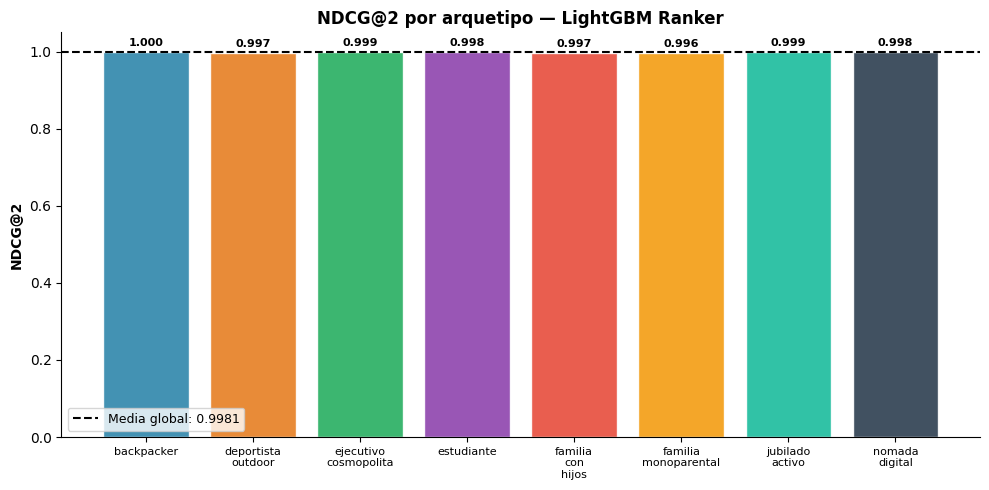

In [5]:
# Predicciones del modelo en validación
scores_val = model.predict(X_val)
df_vl = df_vl.copy()
df_vl['score_pred'] = scores_val

# NDCG@k: calcula la calidad del ordenamiento para cada query y promedia
def compute_ndcg_at_k(df_subset, k=2):
    """Calcula el NDCG@k promedio sobre todos los queries del subset."""
    ndcgs = []
    for _, grp in df_subset.groupby('query_id'):
        true_rel   = grp['relevance'].values.reshape(1, -1)
        pred_score = grp['score_pred'].values.reshape(1, -1)
        # Si todos los docs son irrelevantes, el NDCG es 1.0 por definición
        if true_rel.max() == 0:
            ndcgs.append(1.0)
            continue
        ndcgs.append(sklearn_ndcg(true_rel, pred_score, k=k))
    return float(np.mean(ndcgs))

# Precision@1: ¿la ciudad que el modelo elige primero tiene relevance >= 2?
def compute_precision_at_1(df_subset, threshold=2):
    """Fracción de queries donde la ciudad top-1 tiene relevance >= threshold."""
    hits = 0
    for _, grp in df_subset.groupby('query_id'):
        top1_idx = grp['score_pred'].idxmax()
        rel_top1 = grp.loc[top1_idx, 'relevance']
        hits += int(rel_top1 >= threshold)
    return hits / df_subset['query_id'].nunique()

ndcg_1  = compute_ndcg_at_k(df_vl, k=1)
ndcg_2  = compute_ndcg_at_k(df_vl, k=2)
prec_1  = compute_precision_at_1(df_vl)

print('=' * 50)
print('MÉTRICAS DE EVALUACIÓN — Validación')
print('=' * 50)
print(f'  NDCG@1        : {ndcg_1:.4f}')
print(f'  NDCG@2        : {ndcg_2:.4f}  ← igual a NDCG@3, @5 (solo 2 ciudades)')
print(f'  Precision@1   : {prec_1:.4f}  ← ciudad top-1 tiene relevance ≥ 2')
print()

# NDCG@2 desglosado por arquetipo
print('NDCG@2 por arquetipo:')
ndcg_por_arq = {}
for arq in sorted(df_vl['arquetipo'].unique()):
    n = compute_ndcg_at_k(df_vl[df_vl['arquetipo'] == arq], k=2)
    ndcg_por_arq[arq] = n
    bar = '█' * int(n * 25)
    print(f'  {arq:<25} {n:.4f}  {bar}')

# Visualización NDCG por arquetipo
fig, ax = plt.subplots(figsize=(10, 5))
nombres = list(ndcg_por_arq.keys())
valores = list(ndcg_por_arq.values())
bars = ax.bar(range(len(nombres)), valores, color=COLORS_ARQ, edgecolor='white', alpha=0.9)
ax.axhline(ndcg_2, color='black', linestyle='--', linewidth=1.5,
           label=f'Media global: {ndcg_2:.4f}')
ax.set_xticks(range(len(nombres)))
ax.set_xticklabels([n.replace('_', '\n') for n in nombres], fontsize=8)
ax.set_ylabel('NDCG@2', fontweight='bold')
ax.set_title('NDCG@2 por arquetipo — LightGBM Ranker', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
for bar_item, val in zip(bars, valores):
    ax.text(bar_item.get_x() + bar_item.get_width()/2, val + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/lgbm_ndcg_por_arquetipo.png', dpi=150, bbox_inches='tight')
plt.show()

OBSERVACIONES:
- Un NDCG@2 cercano a 1.0 significa que el modelo ordena bien las ciudades
- Con solo 2 ciudades, NDCG@2 = NDCG@3 = NDCG@5 (no hay más documentos que ordenar)
- Archetipos con reglas de relevancia más claras (backpacker, jubilado_activo) tienden a
  tener NDCG más alto porque el pseudo-labeling es más determinista para ellos

ANOTACIONES:
- **NDCG (Normalized Discounted Cumulative Gain):**
  - **DCG@k:** suma la relevancia de los k primeros resultados, pero penaliza las
    posiciones más bajas dividiéndolas por `log2(posición + 1)`.
    DCG@2 = rel_pos1/log2(2) + rel_pos2/log2(3) = rel_pos1 + rel_pos2/1.585
  - **IDCG@k:** el DCG máximo posible (ordenamiento perfecto)
  - **NDCG@k = DCG@k / IDCG@k** → siempre entre 0 y 1
  - Un NDCG@1 = 0.85 significa que el 85% de las veces el modelo elige la ciudad
    más relevante en primera posición.
- **Precision@1 con umbral 2:** no mide el orden, mide si la ciudad top-1 es
  "suficientemente relevante" (relevance ≥ 2). Es una métrica de negocio más intuitiva:
  *¿le recomendamos una buena ciudad?*
- **¿Por qué NDCG@k con k > 2 no aporta información aquí?** Con 2 documentos por query,
  NDCG@3 miraría los primeros 3 documentos pero solo hay 2. sklearn trunca k al número
  de documentos, así que NDCG@3 = NDCG@2. En producción, con más ciudades,
  NDCG@3 y NDCG@5 sí serán distintos y relevantes.

---
## Paso 5: Feature Importance del modelo

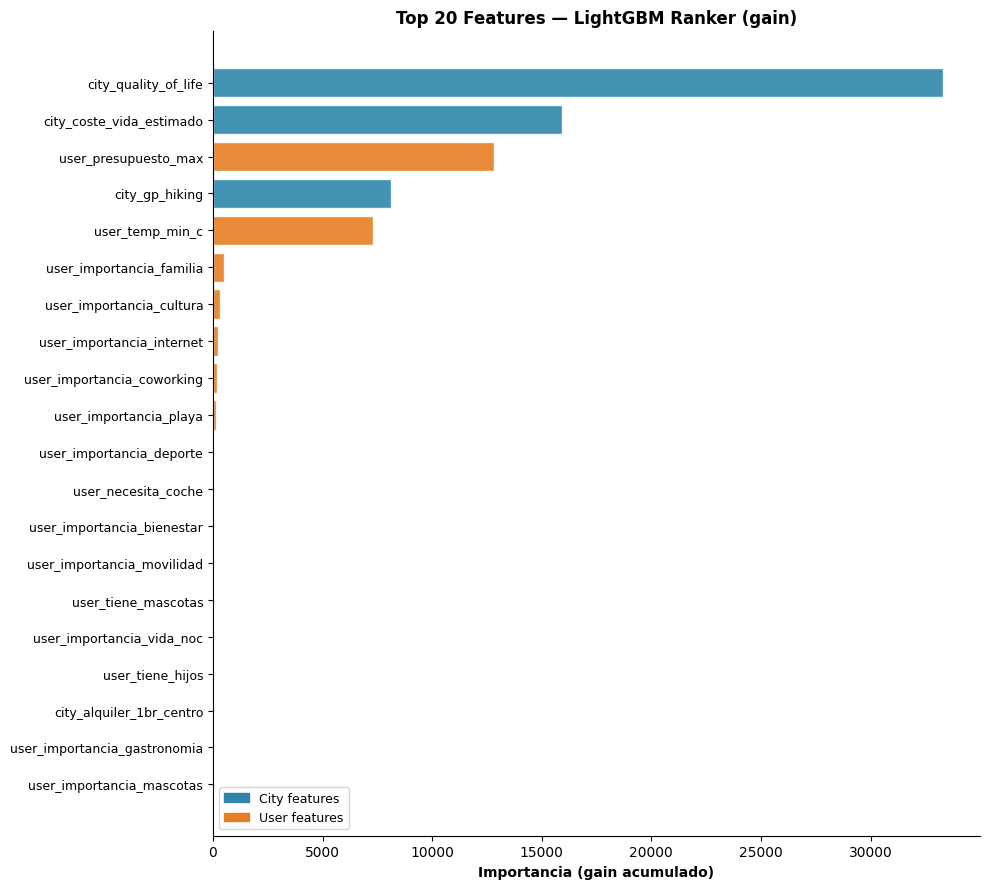

Top 10 features más importantes:
  [city] city_quality_of_life                        33329.4
  [city] city_coste_vida_estimado                    15901.8
  [user] user_presupuesto_max                        12814.8
  [city] city_gp_hiking                               8114.0
  [user] user_temp_min_c                              7280.9
  [user] user_importancia_familia                      485.1
  [user] user_importancia_cultura                      331.5
  [user] user_importancia_internet                     235.4
  [user] user_importancia_coworking                    165.0
  [user] user_importancia_playa                        140.9

Features con importancia 0: 72
  ['user_importancia_bienestar', 'user_importancia_movilidad', 'user_tiene_mascotas', 'user_importancia_vida_noc', 'user_tiene_hijos', 'city_alquiler_1br_centro', 'user_importancia_gastronomia', 'user_importancia_mascotas', 'city_transport_monthly', 'city_alquiler_1br_fuera', 'city_meal_cheap', 'city_basic_utilities', 'city

In [6]:
# Importance type 'gain': reducción total del error atribuida a cada feature
# Es más informativo que 'split' (número de veces que se usa la feature)
importance_gain = pd.Series(
    model.feature_importance(importance_type='gain'),
    index=FEATURE_COLS
).sort_values(ascending=False)

top_n = 20
top20 = importance_gain.head(top_n)

# Color azul = city feature, naranja = user feature
colors = ['#2E86AB' if c.startswith('city_') else '#E67E22' for c in top20.index]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(
    range(len(top20)),
    top20.values[::-1],
    color=colors[::-1],
    edgecolor='white', alpha=0.9
)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index[::-1], fontsize=9)
ax.set_xlabel('Importancia (gain acumulado)', fontweight='bold')
ax.set_title(f'Top {top_n} Features — LightGBM Ranker (gain)', fontweight='bold')

patch_city = mpatches.Patch(color='#2E86AB', label='City features')
patch_user = mpatches.Patch(color='#E67E22', label='User features')
ax.legend(handles=[patch_city, patch_user], fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/lgbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features más importantes:')
for feat, val in top20.head(10).items():
    tipo = 'city' if feat.startswith('city_') else 'user'
    print(f'  [{tipo}] {feat:<40} {val:>10.1f}')

# Features con importancia 0 (nunca usadas por el modelo)
zero_imp = importance_gain[importance_gain == 0]
print(f'\nFeatures con importancia 0: {len(zero_imp)}')
if len(zero_imp) > 0:
    print(f'  {list(zero_imp.index)}')

OBSERVACIONES:
- Las features de coste (`city_coste_vida_estimado`, `city_alquiler_1br_centro`) suelen
  dominar la importancia porque tienen un peso muy alto en el pseudo-labeling (restricción dura)
- Las features de temperatura (`city_temp_media_anual`, `user_temp_min_c`) también son
  muy importantes — el clima es un factor decisivo para casi todos los arquetipos
- Features con importancia 0 son features que el modelo nunca eligió como punto de split
  — pueden eliminarse en una versión futura sin perder performance

ANOTACIONES:
- **Feature Importance (gain):** cada vez que el modelo usa una feature para hacer un split
  en un árbol, mide cuánto bajó el error (la 'ganancia'). La suma de todas estas ganancias
  es el `gain` total de esa feature. Features con gain alto son más críticas para el modelo.
- **Feature Importance (split) vs (gain):** `split` cuenta cuántas veces se usa la feature
  sin importar cuánto mejora. Una feature puede aparecer muchas veces pero en splits de
  poca importancia. Por eso `gain` es generalmente más informativo.
- **Diferencia con SHAP:** la importancia de LightGBM es global (promedio sobre todos los
  árboles y muestras). SHAP, en cambio, da un valor de importancia por muestra individual,
  lo que permite explicar predicciones específicas. SHAP lo veremos en el próximo paso.

---
## Paso 6: SHAP — Importancia global de features

Calculando SHAP values...
SHAP values shape: (1000, 84)  →  (1000 muestras x 84 features)


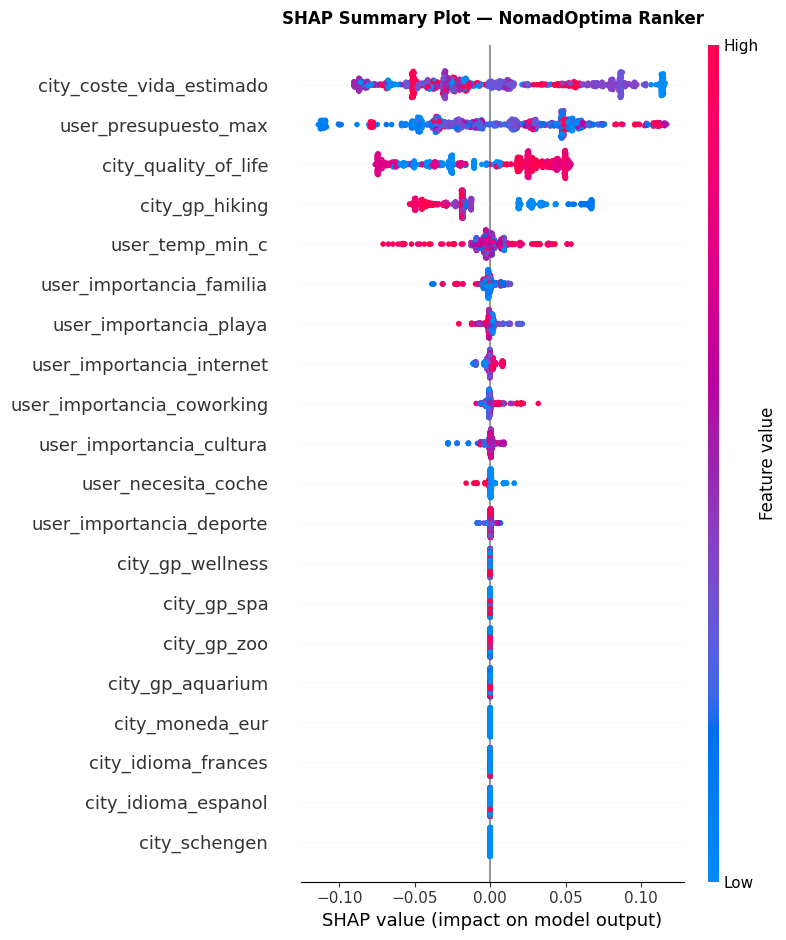

In [7]:
# Muestra representativa para SHAP (usamos 1000 filas para mayor velocidad)
print('Calculando SHAP values...')
sample_size = min(1000, len(X_val))
idx_sample  = np.random.choice(len(X_val), sample_size, replace=False)
X_sample    = X_val[idx_sample]

# TreeExplainer: SHAP exacto para modelos de árboles (LightGBM, XGBoost, etc.)
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print(f'SHAP values shape: {shap_values.shape}  →  ({sample_size} muestras x {len(FEATURE_COLS)} features)')

# Summary plot: cada punto = una muestra; eje X = impacto en la predicción
plt.figure(figsize=(10, 9))
shap.summary_plot(
    shap_values, X_sample,
    feature_names=FEATURE_COLS,
    max_display=20,
    show=False
)
plt.title('SHAP Summary Plot — NomadOptima Ranker', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/processed/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

OBSERVACIONES:
- El SHAP summary plot muestra las 20 features más importantes
- Cada punto es una muestra. El color indica el valor de la feature (rojo = alto, azul = bajo)
- Puntos a la derecha del eje central → esta feature aumenta la relevancia predicha
- Puntos a la izquierda → esta feature reduce la relevancia predicha

ANOTACIONES:
- **SHAP (SHapley Additive exPlanations):** método basado en la teoría de juegos
  (valores de Shapley) para explicar cualquier predicción de ML.
  La idea: ¿cuánto contribuye cada feature a que la predicción sea diferente del promedio?
- **Interpretación de un SHAP value:**
  Si la predicción media del modelo es 1.5 y una muestra tiene predicción 2.3,
  los SHAP values descomponen esa diferencia de +0.8 entre todas las features.
  Por ejemplo: `city_coste_vida_estimado` contribuye +0.3, `user_presupuesto_max` +0.2...
- **TreeExplainer vs otros:** para modelos de árboles, `TreeExplainer` calcula los
  valores SHAP exactos (no aproximados) de forma muy eficiente. Para redes neuronales
  se usaría `DeepExplainer` o `GradientExplainer`, que son aproximaciones.
- **Ventaja de SHAP sobre Feature Importance:** SHAP explica predicciones individuales.
  Podemos decirle al usuario: *"Te recomendamos Málaga porque tu presupuesto
  de 1200€ encaja bien (+0.4 SHAP) y valoras el clima cálido (+0.3 SHAP)"*.
  Esto es lo que haremos en el endpoint /recommend de la FastAPI.

---
## Paso 7: SHAP Waterfall por arquetipo

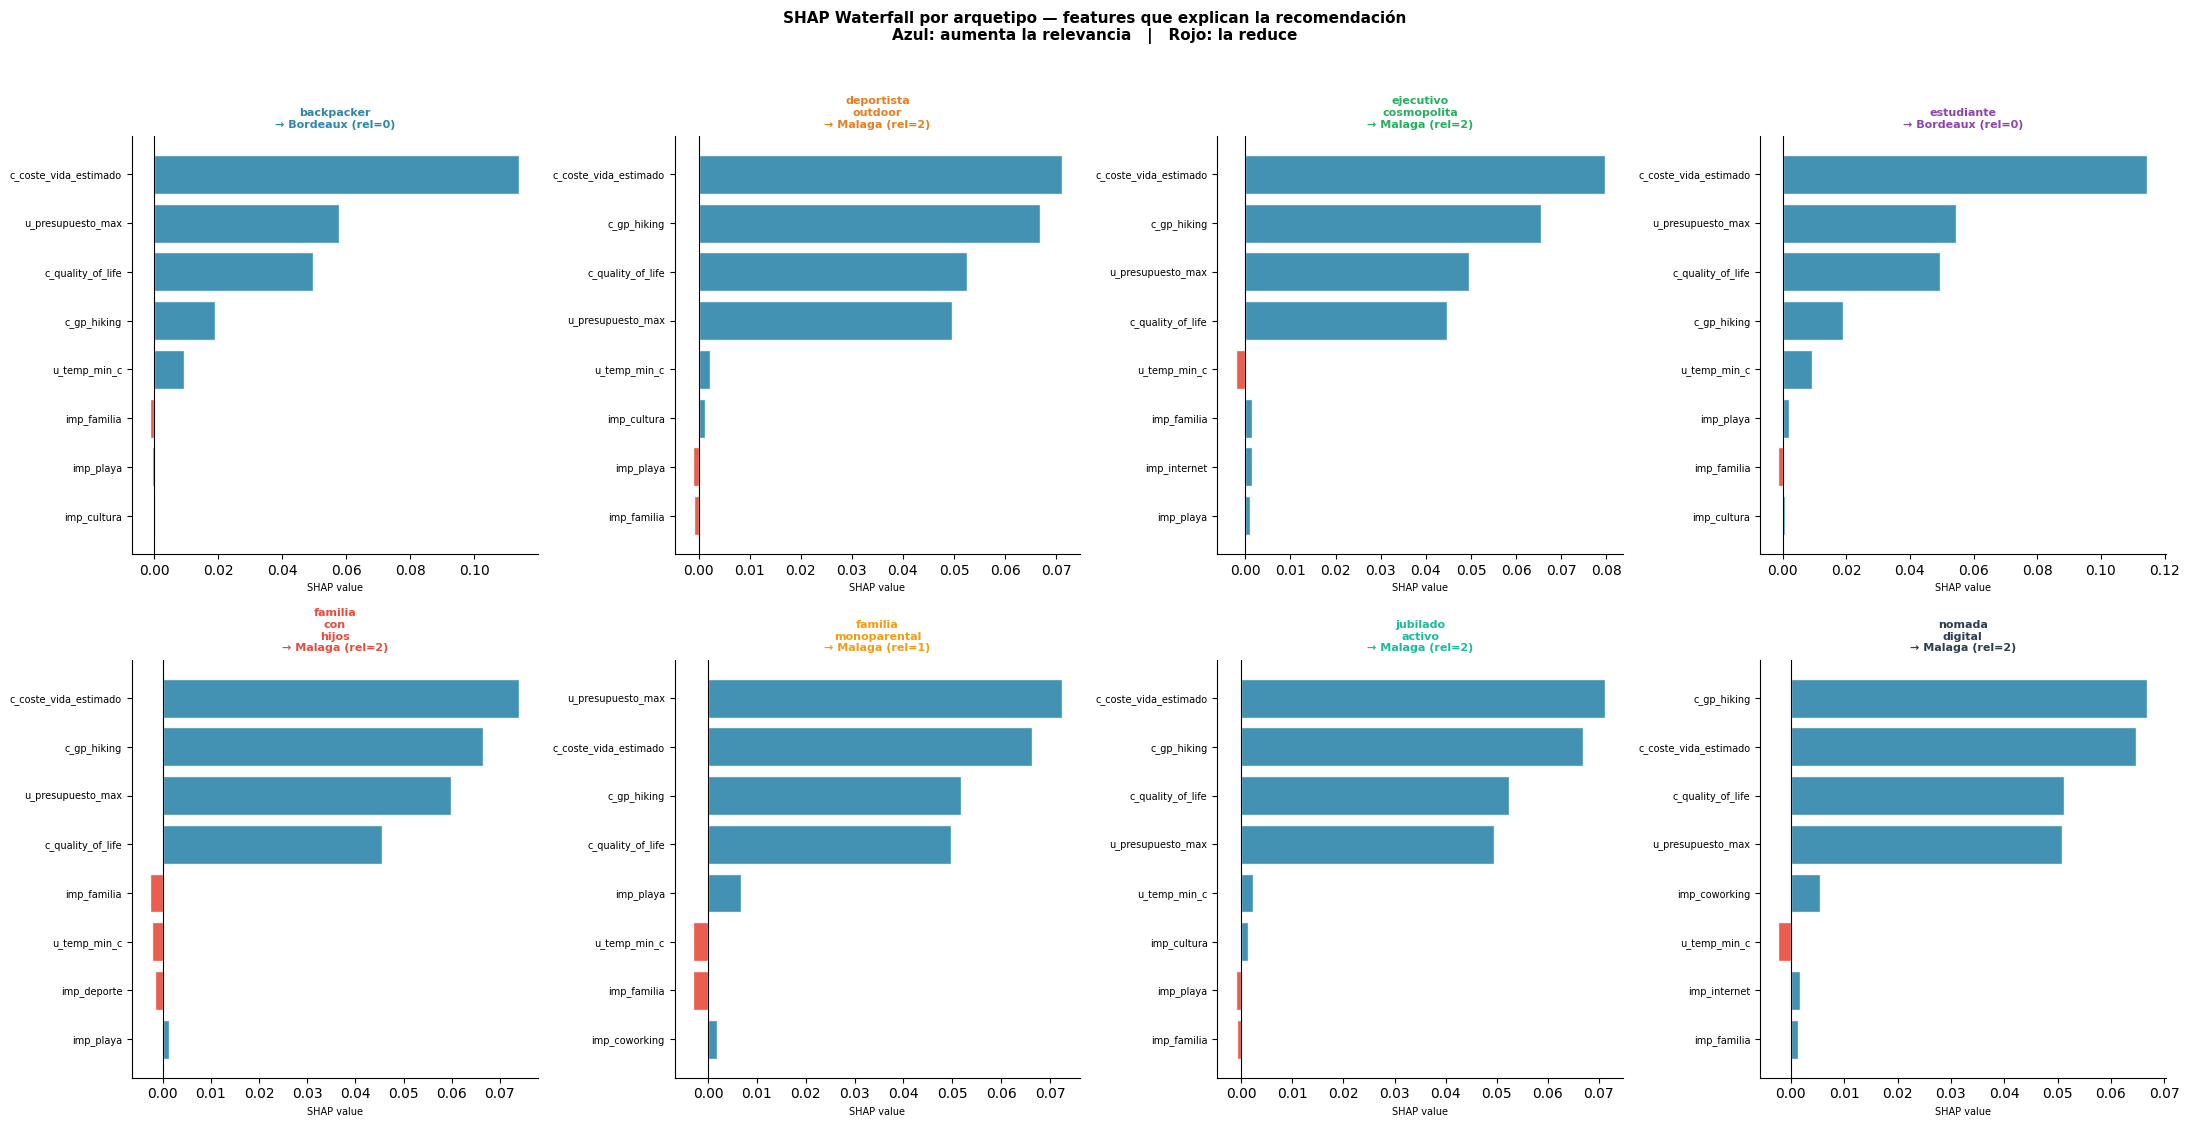

Guardado: data/processed/shap_waterfall_arquetipos.png


In [8]:
# Para cada arquetipo, tomamos un perfil representativo de validación
# y mostramos las 8 features con mayor impacto SHAP en la decisión de ciudad
ARQUETIPOS_LIST = sorted(df_vl['arquetipo'].unique())

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

for idx, arq in enumerate(ARQUETIPOS_LIST):
    mask    = df_vl['arquetipo'] == arq
    first_qid = df_vl[mask]['query_id'].iloc[0]
    grp     = df_vl[df_vl['query_id'] == first_qid]

    # Fila de la ciudad con mayor score predicho (decisión final del modelo)
    best_idx   = grp['score_pred'].idxmax()
    row_pos    = df_vl.index.get_loc(best_idx)

    # SHAP values para esa fila
    sv = explainer.shap_values(X_val[row_pos : row_pos + 1])[0]

    # Top 8 por valor absoluto
    top8_i     = np.argsort(np.abs(sv))[-8:]
    top8_names = [
        FEATURE_COLS[i]
        .replace('user_importancia_', 'imp_')
        .replace('user_', 'u_')
        .replace('city_', 'c_')
        for i in top8_i
    ]
    top8_vals  = sv[top8_i]
    city_recom = grp.loc[best_idx, 'city']
    rel_recom  = grp.loc[best_idx, 'relevance']

    ax = axes[idx]
    bar_colors = ['#2E86AB' if v >= 0 else '#E74C3C' for v in top8_vals]
    ax.barh(range(8), top8_vals, color=bar_colors, edgecolor='white', alpha=0.9)
    ax.set_yticks(range(8))
    ax.set_yticklabels(top8_names, fontsize=7)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP value', fontsize=7)
    ax.set_title(
        f'{arq.replace("_", chr(10))}\n→ {city_recom} (rel={rel_recom})',
        fontweight='bold', fontsize=8, color=COLORS_ARQ[idx]
    )

plt.suptitle(
    'SHAP Waterfall por arquetipo — features que explican la recomendación\n'
    'Azul: aumenta la relevancia   |   Rojo: la reduce',
    fontweight='bold', y=1.02, fontsize=11
)
plt.tight_layout()
plt.savefig('../data/processed/shap_waterfall_arquetipos.png', dpi=150, bbox_inches='tight')
plt.show()

print('Guardado: data/processed/shap_waterfall_arquetipos.png')

OBSERVACIONES:
- Para el `nomada_digital`, las features de coworking y coste deberían dominar
- Para el `deportista_outdoor`, beaches y surf_school deberían tener SHAP alto
- Para el `ejecutivo_cosmopolita`, las features de cultura y gastronomía de París
  deberían empujar hacia Paris (valores SHAP negativos para features de bajo coste)

ANOTACIONES:
- **Waterfall plot:** muestra cómo cada feature empuja la predicción desde el valor base
  (predicción media del modelo) hasta la predicción final para esa muestra.
  Aquí usamos un bar chart horizontal equivalente, más fácil de comparar entre arquetipos.
- **Uso en producción:** cuando un usuario reciba su recomendación, el endpoint /recommend
  calculará estos SHAP values y devolverá una explicación en lenguaje natural:
  *"Málaga encaja con tu perfil porque: [top 3 razones SHAP]"*
- **Por qué SHAP es clave para el portfolio:** en entrevistas técnicas, tener
  explainability demuestra que entiendes no solo que el modelo funciona, sino
  por qué funciona. Diferencia un sistema de ML de una caja negra.

---
## Paso 8: MLflow — Tracking del experimento

In [9]:
# MLflow registra parámetros, métricas y artefactos del experimento
# Así podemos comparar distintas versiones del modelo de forma reproducible
mlflow.set_experiment('NomadOptima_LightGBM_Ranker')

with mlflow.start_run(run_name='lgbm_ranker_v1') as run:

    # ── Parámetros del modelo ──────────────────────────────────────────────
    mlflow.log_params({
        'objective':            PARAMS['objective'],
        'num_leaves':           PARAMS['num_leaves'],
        'learning_rate':        PARAMS['learning_rate'],
        'min_child_samples':    PARAMS['min_child_samples'],
        'feature_fraction':     PARAMS['feature_fraction'],
        'bagging_fraction':     PARAMS['bagging_fraction'],
        'n_iteraciones_usadas': model.num_trees(),
        'n_features':           len(FEATURE_COLS),
        'n_train_queries':      len(train_queries),
        'n_val_queries':        len(val_queries),
        'ciudades':             ','.join(df['city'].unique().tolist()),
        'n_arquetipos':         len(ARQUETIPOS_LIST),
        'pseudo_label_scale':   '0-3',
    })

    # ── Métricas globales ──────────────────────────────────────────────────
    mlflow.log_metrics({
        'ndcg_at_1':      ndcg_1,
        'ndcg_at_2':      ndcg_2,
        'precision_at_1': prec_1,
    })

    # ── Métricas por arquetipo ─────────────────────────────────────────────
    for arq, n_val in ndcg_por_arq.items():
        mlflow.log_metric(f'ndcg_at_2_{arq}', n_val)

    # ── Guardar modelo ─────────────────────────────────────────────────────
    mlflow.lightgbm.log_model(model, artifact_path='lgbm_ranker_model')

    # ── Guardar artefactos visuales ────────────────────────────────────────
    for png in [
        '../data/processed/lgbm_ndcg_por_arquetipo.png',
        '../data/processed/lgbm_feature_importance.png',
        '../data/processed/shap_summary.png',
        '../data/processed/shap_waterfall_arquetipos.png',
    ]:
        if os.path.exists(png):
            mlflow.log_artifact(png)

    run_id = run.info.run_id

print('=' * 50)
print('EXPERIMENTO REGISTRADO EN MLFLOW')
print('=' * 50)
print(f'  Experiment  : NomadOptima_LightGBM_Ranker')
print(f'  Run name    : lgbm_ranker_v1')
print(f'  Run ID      : {run_id}')
print(f'  NDCG@1      : {ndcg_1:.4f}')
print(f'  NDCG@2      : {ndcg_2:.4f}')
print(f'  Precision@1 : {prec_1:.4f}')
print()
print('Para ver los resultados:')
print('  Terminal → mlflow ui')
print('  Browser  → http://127.0.0.1:5000')

2026/04/05 23:47:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


EXPERIMENTO REGISTRADO EN MLFLOW
  Experiment  : NomadOptima_LightGBM_Ranker
  Run name    : lgbm_ranker_v1
  Run ID      : 12e2159e3bb44ecf8ae3f713682a9a39
  NDCG@1      : 0.9986
  NDCG@2      : 0.9981
  Precision@1 : 0.5913

Para ver los resultados:
  Terminal → mlflow ui
  Browser  → http://127.0.0.1:5000


OBSERVACIONES:
- El modelo queda registrado en `mlruns/` con todos sus parámetros y métricas
- Si corremos el notebook de nuevo con distintos hiperparámetros, MLflow guarda
  una nueva versión y podemos comparar ambas en la UI

ANOTACIONES:
- **MLflow:** plataforma open-source para el ciclo de vida de modelos de ML.
  Sus 4 componentes principales:
  - **Tracking:** registra parámetros, métricas y artefactos de cada run
  - **Projects:** empaqueta el código para reproducibilidad
  - **Models:** formato estándar para servir modelos (REST, batch, etc.)
  - **Registry:** gestión de versiones de modelos (staging → production)
- **¿Por qué MLflow y no W&B o Comet?** MLflow es 100% open-source, se puede
  instalar localmente sin cuenta externa, y tiene integración nativa con LightGBM.
  Para un proyecto de bootcamp es ideal porque no tiene costes.
- **`mlflow.lightgbm.log_model`:** guarda el modelo en formato MLflow que incluye
  el código de inferencia, las dependencias y metadata. Permite cargarlo después
  con `mlflow.lightgbm.load_model(uri)` para servir predicciones desde FastAPI.
- **Para una entrevista:** *"Uso MLflow para reproducibilidad. Cada experimento
  queda registrado con sus parámetros, métricas y artefactos. Si en producción
  el modelo degrada, puedo volver a cualquier versión anterior en un clic."*

---
## Paso 9: Resumen y conclusiones

In [10]:
print('=' * 58)
print('RESUMEN — NOTEBOOK 03: LIGHTGBM RANKER')
print('=' * 58)
print()
print('MODELO')
print(f'  Tipo          : LightGBM LambdaRank')
print(f'  Árboles       : {model.num_trees()}')
print(f'  Features      : {len(FEATURE_COLS)}')
print(f'  Train queries : {len(train_queries):,}')
print(f'  Val queries   : {len(val_queries):,}')
print()
print('MÉTRICAS')
print(f'  NDCG@1        : {ndcg_1:.4f}')
print(f'  NDCG@2        : {ndcg_2:.4f}')
print(f'  Precision@1   : {prec_1:.4f}')
print()
print('ARTEFACTOS GENERADOS')
artifacts = [
    'data/processed/lgbm_ndcg_por_arquetipo.png',
    'data/processed/lgbm_feature_importance.png',
    'data/processed/shap_summary.png',
    'data/processed/shap_waterfall_arquetipos.png',
]
for a in artifacts:
    existe = os.path.exists(f'../{a}')
    print(f'  [{"OK" if existe else "FALTA"}] {a}')
print()
print('MLFLOW')
print(f'  Experiment    : NomadOptima_LightGBM_Ranker')
print(f'  Run ID        : {run_id[:8]}...')
print(f'  Ver UI        : mlflow ui → http://127.0.0.1:5000')
print()
print('SIGUIENTE PASO')
print('  → Crear src/models/ranker.py')
print('    Clase NomadRanker con fit(), predict(), explain()')
print('  → Crear api/main.py')
print('    FastAPI con endpoint POST /recommend')
print('=' * 58)

RESUMEN — NOTEBOOK 03: LIGHTGBM RANKER

MODELO
  Tipo          : LightGBM LambdaRank
  Árboles       : 2
  Features      : 84
  Train queries : 24,000
  Val queries   : 6,000

MÉTRICAS
  NDCG@1        : 0.9986
  NDCG@2        : 0.9981
  Precision@1   : 0.5913

ARTEFACTOS GENERADOS
  [OK] data/processed/lgbm_ndcg_por_arquetipo.png
  [OK] data/processed/lgbm_feature_importance.png
  [OK] data/processed/shap_summary.png
  [OK] data/processed/shap_waterfall_arquetipos.png

MLFLOW
  Experiment    : NomadOptima_LightGBM_Ranker
  Run ID        : 12e2159e...
  Ver UI        : mlflow ui → http://127.0.0.1:5000

SIGUIENTE PASO
  → Crear src/models/ranker.py
    Clase NomadRanker con fit(), predict(), explain()
  → Crear api/main.py
    FastAPI con endpoint POST /recommend


OBSERVACIONES:
- El notebook 03 completa la fase de modelado del MVP
- Tenemos un modelo entrenado, evaluado con métricas estándar, explicable con SHAP
  y registrado en MLflow — los 4 pilares de un sistema de ML profesional

ANOTACIONES — RESUMEN CONCEPTUAL DEL NOTEBOOK:

1. **Learning to Rank:** ordenar documentos por relevancia dado un query.
   Más adecuado que clasificación/regresión cuando el *orden* importa más que el valor exacto.

2. **LambdaRank / LightGBM:** algoritmo de LTR que optimiza directamente el NDCG
   mediante gradientes calculados sobre pares de documentos.

3. **NDCG:** métrica estándar para ranking. Penaliza colocar documentos relevantes
   en posiciones bajas. NDCG=1 = ordenamiento perfecto.

4. **SHAP:** técnica para explicar predicciones individuales de cualquier modelo de ML.
   Esencial para sistemas de recomendación donde el usuario necesita entender *por qué*.

5. **MLflow:** plataforma de tracking para registrar experimentos, comparar versiones
   y gestionar el ciclo de vida del modelo.

DECISIÓN:
- El modelo entrenado con pseudo-labels de notebook 02 es suficiente para el MVP.
  En una versión futura, con feedback real de usuarios, se puede re-entrenar con
  labels reales (online learning o periodic retraining).
- Los hiperparámetros usados son conservadores. Como siguiente mejora se puede
  hacer `optuna` o `hyperopt` para búsqueda automática de hiperparámetros.